# **NBA Media Value Prediction: From Viewership to Financial Exposure**
The primary objective of this notebook is to evaluate the feasibility and accuracy of predicting the financial media value of NBA game highlights. 

The analytical workflow is structured into two main phases:
1.  **Viewership Prediction:** First, we build models to predict the number of views per game. We evaluate performance using standard regression metrics to establish a baseline of how well we can forecast audience size.
2.  **Financial Valuation:** We then integrate historical data, including technical quality scores (clarity, logo visibility) and highlight duration. By combining our viewership predictions with these arena-specific technical metrics, we derive an estimated media value and compare it against the "ground truth" (actual calculated values) to measure the business impact of prediction errors.

## **2. Configuration & Initialization**

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Configuration
pd.set_option("display.max_columns", None)

In [100]:
# 1. Load Metadata (Highlight URLs & Views)
df_metadata = pd.read_csv("Data/urls/game_highlight_urls_2025_26.csv")
display(df_metadata.head(3))

# 2. Load Game Info and Merge Views
df_game_info = pd.read_csv("Data/exposure_and_game_info/nba_games_2025-26.csv")

# Aggregate views by game_id and map to game info
view_per_game = df_metadata.groupby('game_id')['view_count'].sum()
df_game_info['view_per_game'] = df_game_info['GAME_ID'].map(view_per_game)

# Drop missing values
# Missing values were created when adding view counts. Verification confirmed 
# these correspond exclusively to G-League game IDs, so we can safely drop these rows.
df_game_info = df_game_info.dropna()
display(df_game_info.head(3))

# 3. Load Player Stats
df_player_info = pd.read_csv("Data/exposure_and_game_info/nba_players_stats_2025-26.csv")
display(df_player_info.head(3))

,game_id,title,url,video_id,channel,duration,view_count,like_count,comment_count
0,22500431,Los Angeles Clippers vs Portland Trail Blazers...,https://www.youtube.com/watch?v=11LdwX87xkY,11LdwX87xkY,GAMETIME HIGHLIGHTS,587,99233,1011,64.0
1,22500409,Charlotte Hornets vs Washington Wizards Full G...,https://www.youtube.com/watch?v=IrpfL0OcIuI,IrpfL0OcIuI,GAMETIME HIGHLIGHTS,585,26200,396,32.0
2,22500424,Charlotte Hornets vs Orlando Magic Full Game H...,https://www.youtube.com/watch?v=l5ir1TZxJjk,l5ir1TZxJjk,GAMETIME HIGHLIGHTS,576,25306,347,31.0


,HOME_TEAM_ID,HOME_TEAM_ABBREVIATION,HOME_TEAM_NAME,GAME_ID,GAME_DATE,MIN,HOME_PTS,HOME_FGM,HOME_FGA,HOME_FG_PCT,HOME_FG3M,HOME_FG3A,HOME_FG3_PCT,HOME_FTM,HOME_FTA,HOME_FT_PCT,HOME_OREB,HOME_DREB,HOME_REB,HOME_AST,HOME_STL,HOME_BLK,HOME_TOV,HOME_PF,HOME_PLUS_MINUS,AWAY_TEAM_ID,AWAY_TEAM_ABBREVIATION,AWAY_TEAM_NAME,AWAY_PTS,AWAY_FGM,AWAY_FGA,AWAY_FG_PCT,AWAY_FG3M,AWAY_FG3A,AWAY_FG3_PCT,AWAY_FTM,AWAY_FTA,AWAY_FT_PCT,AWAY_OREB,AWAY_DREB,AWAY_REB,AWAY_AST,AWAY_STL,AWAY_BLK,AWAY_TOV,AWAY_PF,AWAY_PLUS_MINUS,view_per_game
1,1610612764,WAS,Washington Wizards,22500498,2026-01-04,240,115,43,88,0.489,12,36,0.333,17,19,0.895,9,26,35,21,9,5,19,20,-26.0,1610612750,MIN,Minnesota Timberwolves,141,55,98,0.561,11,37,0.297,20,27,0.741,17,34,51,29,14,6,14,17,26.0,12868.0
2,1610612758,SAC,Sacramento Kings,22500500,2026-01-04,240,98,34,80,0.425,5,25,0.200,25,32,0.781,6,32,38,17,10,7,10,22,-17.0,1610612749,MIL,Milwaukee Bucks,115,39,87,0.448,10,37,0.270,27,30,0.900,12,36,48,23,4,2,13,21,17.0,7304.0
3,1610612756,PHX,Phoenix Suns,22500499,2026-01-04,241,108,35,79,0.443,17,43,0.395,21,29,0.724,12,37,49,21,2,1,15,23,3.0,1610612760,OKC,Oklahoma City Thunder,105,39,82,0.476,10,32,0.313,17,19,0.895,2,27,29,20,2,4,9,20,-3.0,148671.0


,GAME_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_CITY,PLAYER_ID,PLAYER_NAME,NICKNAME,START_POSITION,COMMENT,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TO,PF,PTS,PLUS_MINUS
0,2022500025,1612709932,MCC,Motor City,1631111,Wendell Moore Jr.,Wendell,F,NaN,33:49,4.0,11.0,0.364,2.0,5.0,0.400,0.0,0.0,0.00,1.0,6.0,7.0,5.0,0.0,1.0,3.0,4.0,10.0,-3.0
1,2022500025,1612709932,MCC,Motor City,1642578,John Ukomadu,John,F,NaN,29:23,4.0,8.0,0.500,1.0,3.0,0.333,0.0,0.0,0.00,3.0,1.0,4.0,0.0,1.0,2.0,1.0,0.0,9.0,-4.0
2,2022500025,1612709932,MCC,Motor City,1642449,Tolu Smith,Tolu,C,NaN,32:24,7.0,16.0,0.438,0.0,0.0,0.000,3.0,4.0,0.75,10.0,3.0,13.0,6.0,0.0,0.0,2.0,1.0,20.0,-1.0


# Feature engineering

In [101]:
# Chronological Sorting
# Essential to ensure past stats do not include future data
df_game_info = df_game_info.sort_values(by='GAME_DATE', ascending=True).reset_index(drop=True)

# Determine Match Winners (Target for streaks)
df_game_info['HOME_WIN'] = (df_game_info['HOME_PTS'] > df_game_info['AWAY_PTS']).astype(int)
df_game_info['AWAY_WIN'] = (df_game_info['AWAY_PTS'] > df_game_info['HOME_PTS']).astype(int)

# Initialize Pre-Match Stats Columns
# We want to know these stats BEFORE the game starts
df_game_info['HOME_TEAM_wins_before'] = 0
df_game_info['HOME_TEAM_losses_before'] = 0
df_game_info['AWAY_TEAM_wins_before'] = 0
df_game_info['AWAY_TEAM_losses_before'] = 0
df_game_info['HOME_TEAM_streak_before'] = 0  # Positive = Win Streak, Negative = Loss Streak
df_game_info['AWAY_TEAM_streak_before'] = 0

# Conference Feature (Static)
# Set of Eastern Conference Team IDs
east_teams = {
    1610612738, 1610612751, 1610612752, 1610612755, 1610612761, 
    1610612741, 1610612739, 1610612765, 1610612754, 1610612749, 
    1610612737, 1610612766, 1610612748, 1610612753, 1610612764
}

# Create binary conference variables (1 = East, 0 = West)
df_game_info['HOME_TEAM_is_east'] = df_game_info['HOME_TEAM_ID'].isin(east_teams).astype(int)
df_game_info['AWAY_TEAM_is_east'] = df_game_info['AWAY_TEAM_ID'].isin(east_teams).astype(int)

# Iterative Calculation of Cumulative Stats (Wins/Losses/Streaks)
# Using a dictionary to track state as we iterate through time
team_stats = {}

for idx, row in df_game_info.iterrows():
    home_team = row['HOME_TEAM_ID']
    away_team = row['AWAY_TEAM_ID']
    
    # Initialize team if encountered for the first time
    if home_team not in team_stats:
        team_stats[home_team] = {'wins': 0, 'losses': 0, 'streak': 0}
    if away_team not in team_stats:
        team_stats[away_team] = {'wins': 0, 'losses': 0, 'streak': 0}
    
    # A. Assign stats BEFORE the current match
    df_game_info.at[idx, 'HOME_TEAM_wins_before'] = team_stats[home_team]['wins']
    df_game_info.at[idx, 'HOME_TEAM_losses_before'] = team_stats[home_team]['losses']
    df_game_info.at[idx, 'AWAY_TEAM_wins_before'] = team_stats[away_team]['wins']
    df_game_info.at[idx, 'AWAY_TEAM_losses_before'] = team_stats[away_team]['losses']
    
    df_game_info.at[idx, 'HOME_TEAM_streak_before'] = team_stats[home_team]['streak']
    df_game_info.at[idx, 'AWAY_TEAM_streak_before'] = team_stats[away_team]['streak']
    
    # B. Update stats AFTER the match (for the next iteration)
    if row['HOME_WIN'] == 1:
        # Home Win
        team_stats[home_team]['wins'] += 1
        team_stats[away_team]['losses'] += 1
        
        # Update Home Streak (W)
        if team_stats[home_team]['streak'] >= 0:
            team_stats[home_team]['streak'] += 1
        else:
            team_stats[home_team]['streak'] = 1
            
        # Update Away Streak (L)
        if team_stats[away_team]['streak'] <= 0:
            team_stats[away_team]['streak'] -= 1
        else:
            team_stats[away_team]['streak'] = -1
    else:
        # Away Win
        team_stats[home_team]['losses'] += 1
        team_stats[away_team]['wins'] += 1
        
        # Update Home Streak (L)
        if team_stats[home_team]['streak'] <= 0:
            team_stats[home_team]['streak'] -= 1
        else:
            team_stats[home_team]['streak'] = -1
            
        # Update Away Streak (W)
        if team_stats[away_team]['streak'] >= 0:
            team_stats[away_team]['streak'] += 1
        else:
            team_stats[away_team]['streak'] = 1

# Calculated Ratios (Win %)
# Total games played before
df_game_info['HOME_TEAM_games_before'] = df_game_info['HOME_TEAM_wins_before'] + df_game_info['HOME_TEAM_losses_before']
df_game_info['AWAY_TEAM_games_before'] = df_game_info['AWAY_TEAM_wins_before'] + df_game_info['AWAY_TEAM_losses_before']

# Win Percentage (default to 0.5 for first game)
df_game_info['HOME_TEAM_winpct_before'] = df_game_info.apply(
    lambda x: x['HOME_TEAM_wins_before'] / x['HOME_TEAM_games_before'] 
    if x['HOME_TEAM_games_before'] > 0 else 0.5, axis=1
)
df_game_info['AWAY_TEAM_winpct_before'] = df_game_info.apply(
    lambda x: x['AWAY_TEAM_wins_before'] / x['AWAY_TEAM_games_before'] 
    if x['AWAY_TEAM_games_before'] > 0 else 0.5, axis=1
)

# Readable Streak Labels (e.g., "W3", "L2")
df_game_info['HOME_TEAM_streak_label'] = df_game_info['HOME_TEAM_streak_before'].apply(
    lambda x: f"W{x}" if x > 0 else (f"L{abs(x)}" if x < 0 else "-")
)
df_game_info['AWAY_TEAM_streak_label'] = df_game_info['AWAY_TEAM_streak_before'].apply(
    lambda x: f"W{x}" if x > 0 else (f"L{abs(x)}" if x < 0 else "-")
)

# ROLLING AVERAGES (LAST 5 GAMES)
WINDOW = 5

# Create "Long Format" Dataset (1 row per team per game)
df_games_unique = df_game_info.drop_duplicates(['GAME_ID']).copy()
df_games_unique['GAME_DATE'] = pd.to_datetime(df_games_unique['GAME_DATE'])

# Process HOME teams
cols_home = [c for c in df_games_unique.columns if "HOME_" in c]
df_home = df_games_unique[['GAME_ID', 'GAME_DATE', 'view_per_game'] + cols_home].copy()
rename_dict_home = {c: c.replace('HOME_', '') for c in cols_home}
rename_dict_home['HOME_TEAM_ID'] = 'TEAM_ID'
df_home = df_home.rename(columns=rename_dict_home)

# Process AWAY teams
cols_away = [c for c in df_games_unique.columns if "AWAY_" in c]
df_away = df_games_unique[['GAME_ID', 'GAME_DATE', 'view_per_game'] + cols_away].copy()
rename_dict_away = {c: c.replace('AWAY_', '') for c in cols_away}
rename_dict_away['AWAY_TEAM_ID'] = 'TEAM_ID'
df_away = df_away.rename(columns=rename_dict_away)

# Concatenate and sort
df_team_stats = pd.concat([df_home, df_away], ignore_index=True)
df_team_stats = df_team_stats.sort_values(by=['TEAM_ID', 'GAME_DATE'])


# Columns to EXCLUDE from rolling average calculation
# We exclude IDs, Booleans, cumulative stats, and static features
exclude_cols = [
    'TEAM_wins_before', 'TEAM_losses_before', 
    'TEAM_games_before', 'TEAM_winpct_before',
    'TEAM_conf_rank_before', 'TEAM_league_rank_before',
    'TEAM_streak_before', 'WIN',
    'TEAM_is_east',  # Static variable, no need to roll
    'TEAM_ID', 'GAME_ID'
]

# Identify numeric columns to roll (Performance metrics + Views)
cols_to_roll = [c for c in df_team_stats.select_dtypes(include='number').columns 
                if c not in exclude_cols]

# Apply Rolling Mean with shift(1) to avoid data leakage
df_rolling = df_team_stats.groupby('TEAM_ID')[cols_to_roll].apply(
    lambda x: x.shift(1).rolling(window=WINDOW, min_periods=1).mean()
).reset_index(level=0, drop=True)

# Add suffix
df_rolling = df_rolling.add_suffix('_last5')

# Reattach IDs for merging
df_stats_calculated = pd.concat([df_team_stats[['GAME_ID', 'TEAM_ID']], df_rolling], axis=1)

# Merge Back to Original DataFrame
df_final = df_game_info.copy()

# Merge for HOME Team
df_final = df_final.merge(
    df_stats_calculated,
    left_on=['HOME_TEAM_ID', 'GAME_ID'],
    right_on=['TEAM_ID', 'GAME_ID'],
    how='left'
).drop(columns=['TEAM_ID'])

# Rename columns (e.g., view_per_game_last5 -> HOME_view_per_game_last5)
new_cols = df_rolling.columns
rename_dict_final_home = {c: f"HOME_{c}" for c in new_cols}
df_final = df_final.rename(columns=rename_dict_final_home)

# Merge for AWAY Team
df_final = df_final.merge(
    df_stats_calculated,
    left_on=['AWAY_TEAM_ID', 'GAME_ID'],
    right_on=['TEAM_ID', 'GAME_ID'],
    how='left'
).drop(columns=['TEAM_ID'])

# Rename columns
rename_dict_final_away = {c: f"AWAY_{c}" for c in new_cols}
df_final = df_final.rename(columns=rename_dict_final_away)

# Final Contextual Features
# Number of games on the same day (Competitiveness)
df_final['NB_GAMES_THIS_DAY'] = df_final.groupby('GAME_DATE')['GAME_ID'].transform('count')

# Differences (Matchup Context)
df_final['level_difference'] = df_final['HOME_TEAM_winpct_before'] - df_final['AWAY_TEAM_winpct_before']
df_final['conference_difference'] = np.abs(df_final["HOME_TEAM_is_east"] - df_final["AWAY_TEAM_is_east"])

# Preparation for machine learning

In [102]:
# Cleaning and Chronological Sorting
df_clean = df_final.dropna().copy()
#df_clean = df_clean[(df_clean['AWAY_TEAM_ID'] == 1610612747) | (df_clean['HOME_TEAM_ID'] == 1610612747)]
#df_clean = df_clean[df_clean['view_per_game'] > 200000]
df_clean['GAME_DATE'] = pd.to_datetime(df_clean['GAME_DATE'])

# Strict chronological sort to prevent data leakage in time-series split
df_ml = df_clean.sort_values(by='GAME_DATE').reset_index(drop=True)

# Date-Based Feature Engineering
df_ml['month'] = df_ml['GAME_DATE'].dt.month
df_ml['day_of_week'] = df_ml['GAME_DATE'].dt.dayofweek  # 0=Monday, 6=Sunday
df_ml['is_weekend'] = df_ml['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Feature Selection
target = 'view_per_game'

# Explicit list of features to use for prediction
cols_to_keep = [
    'HOME_view_per_game_last5',
    'AWAY_view_per_game_last5',
    'is_weekend',           
    'NB_GAMES_THIS_DAY',
    'HOME_TEAM_winpct_before',
    'AWAY_TEAM_winpct_before'
]

# Verify that columns exist to avoid key errors
features = [c for c in cols_to_keep if c in df_ml.columns]

X = df_ml[features].copy()
y = df_ml[target]
#y = np.log(df_ml[target])

# Automatic One-Hot Encoding
# Detect object or categorical columns automatically
cat_cols = X.select_dtypes(include=['object', 'category']).columns

if len(cat_cols) > 0:
    print(f"--- One-Hot Encoding detected for: {list(cat_cols)} ---")
    # drop_first=True prevents perfect multicollinearity for linear models
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
    
    # CRITICAL: Update the features list to include the new encoded columns
    features = X.columns.tolist()
    print(f"New features list after encoding ({len(features)}): {features}")
else:
    print("--- No categorical variables detected, skipping encoding ---")

# TRAIN / TEST SPLIT & SCALING

# Temporal Split (80/20)
split_pct = 0.80
split_index = int(len(df_ml) * split_pct)

# Slicing based on index (data is already sorted by date)
X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

# Keep metadata for error analysis later
meta_train = df_ml[['GAME_DATE', 'HOME_TEAM_ID', 'AWAY_TEAM_ID']].iloc[:split_index]
meta_test = df_ml[['GAME_DATE', 'HOME_TEAM_ID', 'AWAY_TEAM_ID']].iloc[split_index:]

# Standard Scaling
scaler = StandardScaler()

# A. Fit parameters (mean, std) ONLY on the Train set to avoid data leakage
scaler.fit(X_train)

# B. Transform both sets using Train parameters
X_train_scaled_np = scaler.transform(X_train)
X_test_scaled_np = scaler.transform(X_test)

# C. Convert back to DataFrame to keep column names
X_train_scaled = pd.DataFrame(X_train_scaled_np, columns=features, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled_np, columns=features, index=X_test.index)

--- No categorical variables detected, skipping encoding ---


# Training and evaluating

Mean view value (Target): 219835 

--- Results for: Linear Regression ---
MAE  : 100,507 views
RMSE : 150,103 views
R²   : 0.5318
------------------------------
--- Results for: Ridge (Regularized) ---
MAE  : 100,419 views
RMSE : 150,095 views
R²   : 0.5318
------------------------------
--- Results for: Random Forest ---
MAE  : 92,052 views
RMSE : 148,423 views
R²   : 0.5422
------------------------------


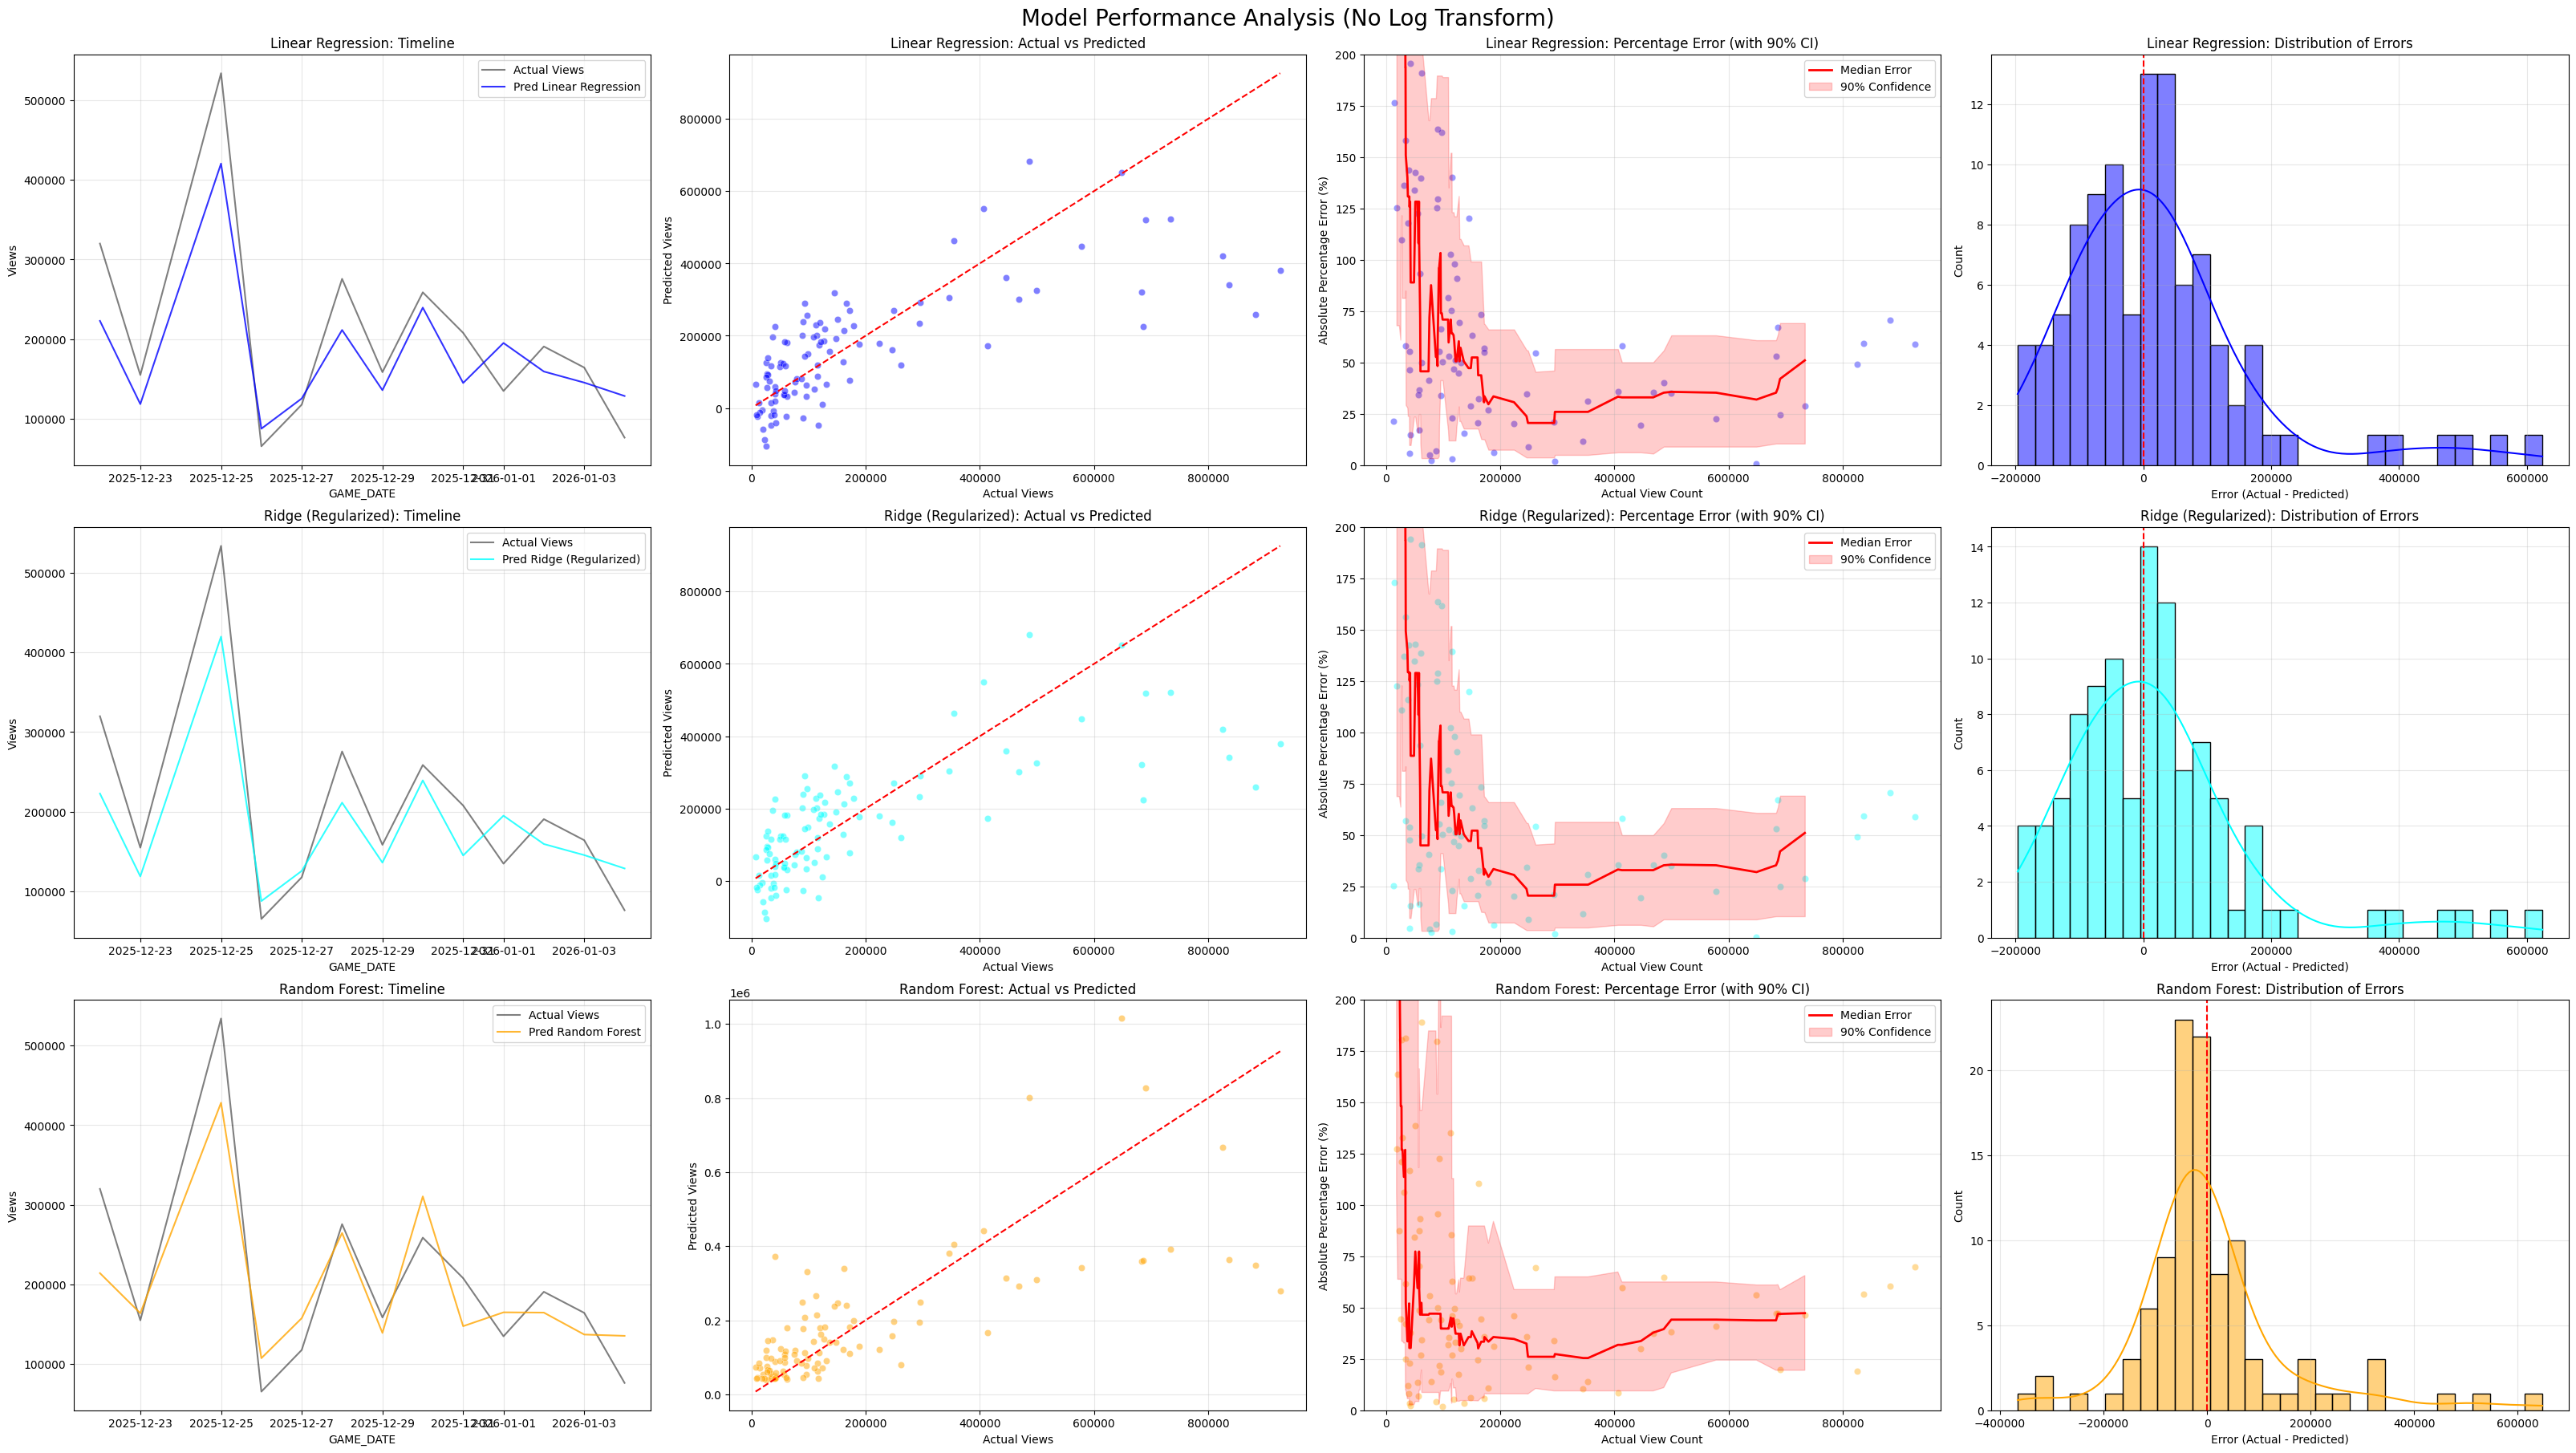


FEATURE IMPORTANCE ANALYSIS


C:\Users\Kyliv\AppData\Local\Temp\ipykernel_107216\1421440348.py:163: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp_linear.head(15), x='Coef', y='Feature', ax=axes[0], palette='vlag', edgecolor='black')
C:\Users\Kyliv\AppData\Local\Temp\ipykernel_107216\1421440348.py:169: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp_ridge.head(15), x='Coef', y='Feature', ax=axes[1], palette='vlag', edgecolor='black')
C:\Users\Kyliv\AppData\Local\Temp\ipykernel_107216\1421440348.py:175: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(da

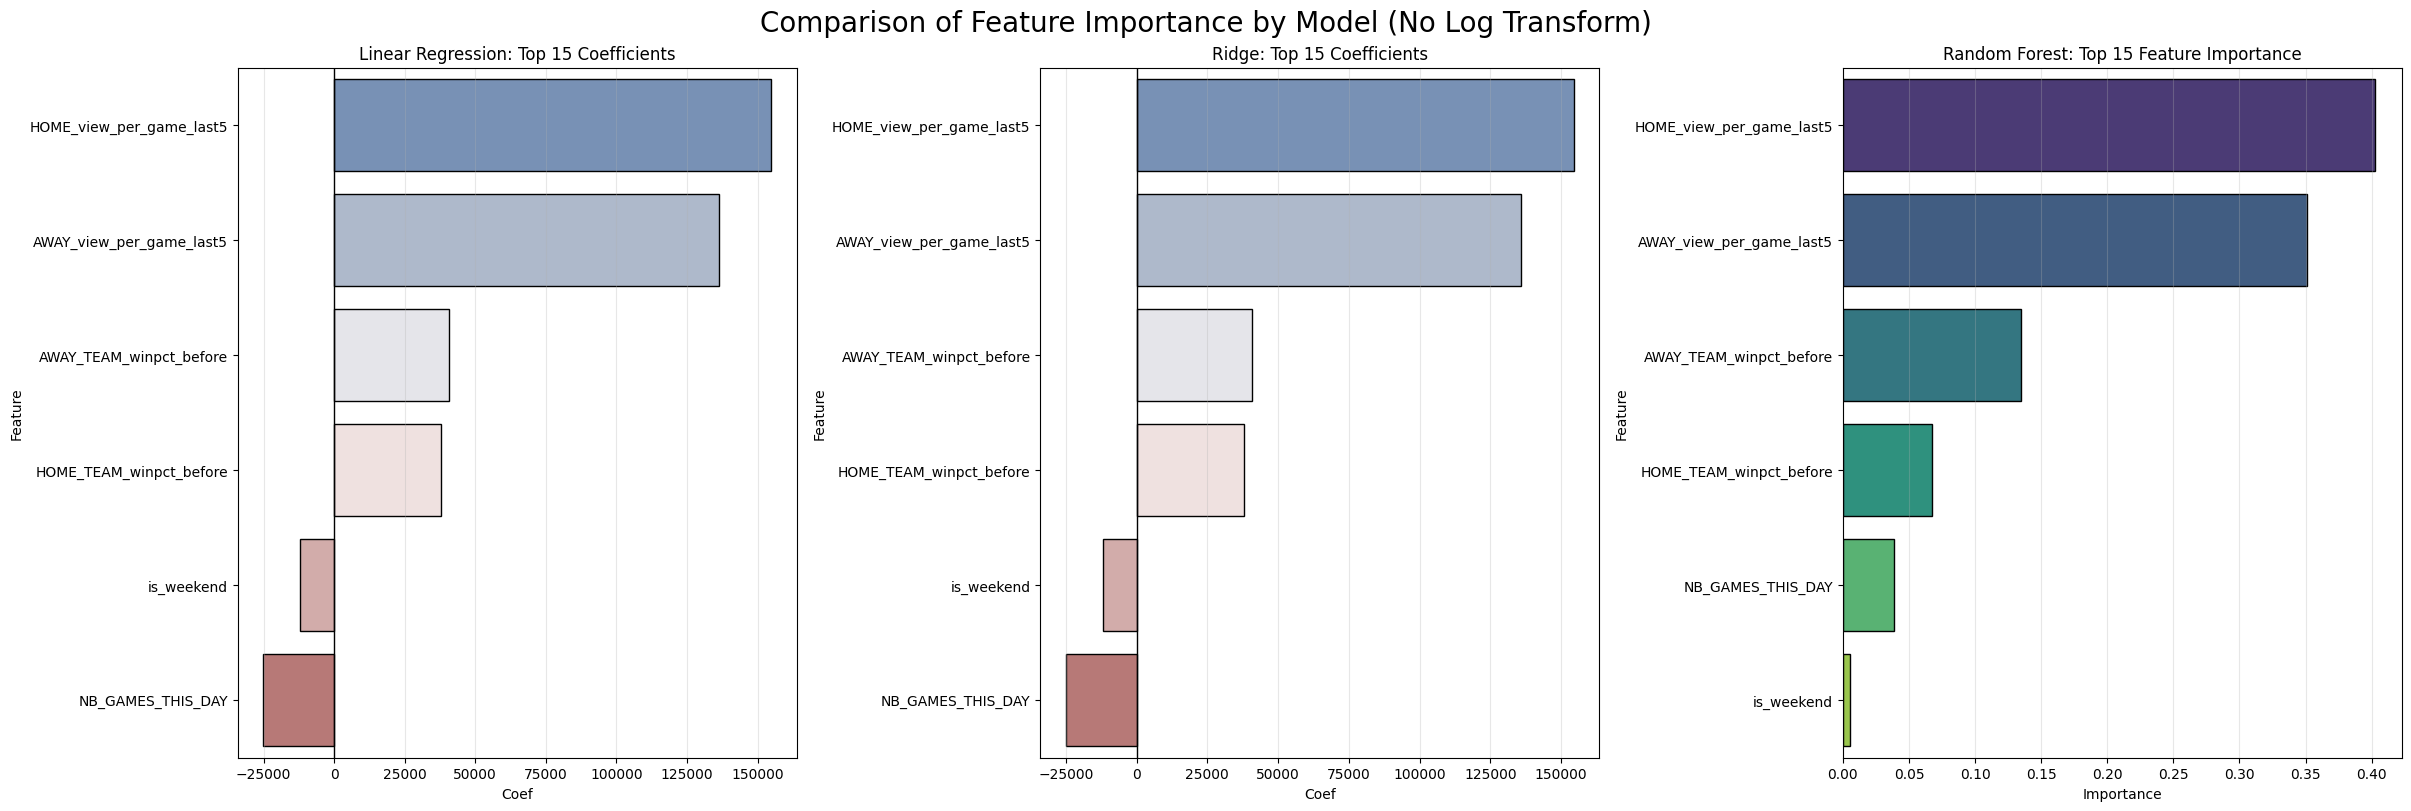

In [103]:
# 6.1 Evaluation Function (No Log Transform)
# ---------------------------------------------------------
def evaluate_model(model, name, X_tr, y_tr, X_te, y_te):
    """Trains the model, predicts, and displays scores."""
    model.fit(X_tr, y_tr)  # Model trains on original y
    
    # Predict directly (no log transform)
    preds_test = model.predict(X_te)
    
    # Calculate metrics on original scale
    mae = mean_absolute_error(y_te, preds_test)
    rmse = np.sqrt(mean_squared_error(y_te, preds_test))
    r2 = r2_score(y_te, preds_test)
    
    print(f"--- Results for: {name} ---")
    print(f"MAE  : {mae:,.0f} views")
    print(f"RMSE : {rmse:,.0f} views")
    print(f"R²   : {r2:.4f}")
    print("-" * 30)
    
    return preds_test  # Return predictions on original scale

# 6.2 Training Loop
# ---------------------------------------------------------
print("Mean view value (Target):", int(y.mean()), "\n")

results = {}

# --- 1. Linear Regression ---
lin_reg = LinearRegression()
results['Linear'] = {
    'model': lin_reg,
    'preds': evaluate_model(lin_reg, "Linear Regression", 
                            X_train_scaled, y_train, X_test_scaled, y_test),
    'color': 'blue'
}

# --- 2. Ridge ---
ridge_reg = Ridge(alpha=1.0)
results['Ridge'] = {
    'model': ridge_reg,
    'preds': evaluate_model(ridge_reg, "Ridge (Regularized)", 
                            X_train_scaled, y_train, X_test_scaled, y_test),
    'color': 'cyan'
}

# --- 3. Random Forest ---
rf_reg = RandomForestRegressor(n_estimators=1000, random_state=24, n_jobs=-1)
results['RandomForest'] = {
    'model': rf_reg,
    'preds': evaluate_model(rf_reg, "Random Forest", 
                            X_train_scaled, y_train, X_test_scaled, y_test),
    'color': 'orange'
}

# 6.3 Performance Visualization
# ---------------------------------------------------------
df_viz = meta_test.copy()
df_viz['Actual'] = y_test  # Use original scale directly

model_names = ['Linear', 'Ridge', 'RandomForest']
display_names = ['Linear Regression', 'Ridge (Regularized)', 'Random Forest']

# Updated Layout: 3 rows, 4 columns
fig, axes = plt.subplots(3, 4, figsize=(32, 18), constrained_layout=True)

for i, name in enumerate(model_names):
    preds = results[name]['preds']  # Already in original scale
    color = results[name]['color']
    disp_name = display_names[i]
    
    # Error calculations
    errors = df_viz['Actual'] - preds       # Real Error (positive or negative)
    abs_errors = np.abs(errors)             # Absolute Error
    
    # --- Column 1: Time Series ---
    sns.lineplot(data=df_viz, x='GAME_DATE', y='Actual', label='Actual Views', 
                 alpha=0.5, color='black', errorbar=None, ax=axes[i, 0])
    sns.lineplot(x=df_viz['GAME_DATE'], y=preds, label=f'Pred {disp_name}', 
                 alpha=0.8, color=color, errorbar=None, ax=axes[i, 0])
    axes[i, 0].set_title(f'{disp_name}: Timeline')
    axes[i, 0].set_ylabel('Views')
    axes[i, 0].grid(True, alpha=0.3)
    
    # --- Column 2: Scatter Plot (Pred vs Actual) ---
    sns.scatterplot(x=df_viz['Actual'], y=preds, alpha=0.5, color=color, ax=axes[i, 1])
    min_val, max_val = df_viz['Actual'].min(), df_viz['Actual'].max()
    axes[i, 1].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')
    axes[i, 1].set_title(f'{disp_name}: Actual vs Predicted')
    axes[i, 1].set_xlabel('Actual Views')
    axes[i, 1].set_ylabel('Predicted Views')
    axes[i, 1].grid(True, alpha=0.3)
    
    # --- Column 3: Percentage Error with Confidence Interval ---
    # Calculate percentage error (avoiding division by zero)
    pct_errors = np.where(df_viz['Actual'] != 0, 
                         (abs_errors / df_viz['Actual']) * 100, 
                         0)
    
    # Plot scatter of percentage errors
    sns.scatterplot(x=df_viz['Actual'], y=pct_errors, alpha=0.4, color=color, ax=axes[i, 2])
    
    # Calculate rolling statistics for confidence interval
    # Sort by actual values for smooth confidence band
    sorted_indices = np.argsort(df_viz['Actual'])
    sorted_actual = df_viz['Actual'].iloc[sorted_indices]
    sorted_pct_errors = pct_errors[sorted_indices]
    
    # Calculate moving average and percentiles (90% confidence interval)
    window_size = max(10, len(sorted_actual) // 20)  # Adaptive window
    rolling_median = pd.Series(sorted_pct_errors).rolling(window=window_size, center=True).median()
    rolling_p5 = pd.Series(sorted_pct_errors).rolling(window=window_size, center=True).quantile(0.05)
    rolling_p95 = pd.Series(sorted_pct_errors).rolling(window=window_size, center=True).quantile(0.95)
    
    # Plot median line and confidence band
    axes[i, 2].plot(sorted_actual, rolling_median, color='red', linewidth=2, label='Median Error')
    axes[i, 2].fill_between(sorted_actual, rolling_p5, rolling_p95, 
                           color='red', alpha=0.2, label='90% Confidence')
    
    axes[i, 2].set_title(f'{disp_name}: Percentage Error (with 90% CI)')
    axes[i, 2].set_xlabel('Actual View Count')
    axes[i, 2].set_ylabel('Absolute Percentage Error (%)')
    axes[i, 2].set_ylim(0, min(200, np.percentile(pct_errors, 99)))  # Cap at 200% or 99th percentile
    axes[i, 2].legend(loc='upper right')
    axes[i, 2].grid(True, alpha=0.3)

    # --- Column 4: Error Distribution ---
    sns.histplot(errors, kde=True, color=color, ax=axes[i, 3], bins=30)
    axes[i, 3].axvline(0, color='red', linestyle='--', label='Zero Error')
    axes[i, 3].set_title(f'{disp_name}: Distribution of Errors')
    axes[i, 3].set_xlabel('Error (Actual - Predicted)')
    axes[i, 3].grid(True, alpha=0.3)

plt.suptitle("Model Performance Analysis (No Log Transform)", fontsize=20)
plt.show()

# 6.4 Feature Importance Analysis
# ---------------------------------------------------------
print("\n" + "="*50)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*50)

# Preparing Importance DataFrames
df_imp_linear = pd.DataFrame({
    'Feature': features, 
    'Coef': results['Linear']['model'].coef_
}).sort_values(by='Coef', ascending=False)

df_imp_ridge = pd.DataFrame({
    'Feature': features, 
    'Coef': results['Ridge']['model'].coef_
}).sort_values(by='Coef', ascending=False)

df_imp_rf = pd.DataFrame({
    'Feature': features, 
    'Importance': results['RandomForest']['model'].feature_importances_
}).sort_values(by='Importance', ascending=False)

# --- Graphical Visualization (Barplots) ---
fig, axes = plt.subplots(1, 3, figsize=(24, 8), constrained_layout=True)

# 1. Linear Regression
sns.barplot(data=df_imp_linear.head(15), x='Coef', y='Feature', ax=axes[0], palette='vlag', edgecolor='black')
axes[0].set_title("Linear Regression: Top 15 Coefficients")
axes[0].axvline(0, color='black', linewidth=1)
axes[0].grid(True, axis='x', alpha=0.3)

# 2. Ridge
sns.barplot(data=df_imp_ridge.head(15), x='Coef', y='Feature', ax=axes[1], palette='vlag', edgecolor='black')
axes[1].set_title("Ridge: Top 15 Coefficients")
axes[1].axvline(0, color='black', linewidth=1)
axes[1].grid(True, axis='x', alpha=0.3)

# 3. Random Forest
sns.barplot(data=df_imp_rf.head(15), x='Importance', y='Feature', ax=axes[2], palette='viridis', edgecolor='black')
axes[2].set_title("Random Forest: Top 15 Feature Importance")
axes[2].grid(True, axis='x', alpha=0.3)

plt.suptitle("Comparison of Feature Importance by Model (No Log Transform)", fontsize=20)
plt.show()

In [104]:
"""""# 6.1 Evaluation Function (Updated for Log-Transformed Target)
# ---------------------------------------------------------
def evaluate_model(model, name, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)  # Model trains on log(y)
    
    # Predict log(y) and transform back to original scale
    preds_test_log = model.predict(X_te)
    preds_test = np.exp(preds_test_log)  # Convert back from log to original scale
    
    # Convert y_test back to original scale for evaluation
    y_te_original = np.exp(y_te)
    
    # Calculate metrics on original scale
    mae = mean_absolute_error(y_te_original, preds_test)
    rmse = np.sqrt(mean_squared_error(y_te_original, preds_test))
    r2 = r2_score(y_te_original, preds_test)
    
    print(f"--- Results for: {name} ---")
    print(f"MAE  : {mae:,.0f} views")
    print(f"RMSE : {rmse:,.0f} views")
    print(f"R²   : {r2:.4f}")
    print("-" * 30)
    
    return preds_test  # Return predictions on original scale

# 6.2 Training Loop
# ---------------------------------------------------------
# Note: y_train and y_test should now be log(views)
print("Mean log(views) value (Target):", y.mean())
print("Mean views (original scale):", int(np.exp(y.mean())), "\n")

results = {}

# --- 1. Linear Regression ---
lin_reg = LinearRegression()
results['Linear'] = {
    'model': lin_reg,
    'preds': evaluate_model(lin_reg, "Linear Regression", 
                            X_train_scaled, y_train, X_test_scaled, y_test),
    'color': 'blue'
}

# --- 2. Ridge ---
ridge_reg = Ridge(alpha=1.0)
results['Ridge'] = {
    'model': ridge_reg,
    'preds': evaluate_model(ridge_reg, "Ridge (Regularized)", 
                            X_train_scaled, y_train, X_test_scaled, y_test),
    'color': 'cyan'
}

# --- 3. Random Forest ---
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
results['RandomForest'] = {
    'model': rf_reg,
    'preds': evaluate_model(rf_reg, "Random Forest", 
                            X_train_scaled, y_train, X_test_scaled, y_test),
    'color': 'orange'
}

# 6.3 Performance Visualization
# ---------------------------------------------------------
df_viz = meta_test.copy()
df_viz['Actual'] = np.exp(y_test)  # Convert back to original scale for visualization

model_names = ['Linear', 'Ridge', 'RandomForest']
display_names = ['Linear Regression', 'Ridge (Regularized)', 'Random Forest']

# Updated Layout: 3 rows, 4 columns (added Error Distribution)
fig, axes = plt.subplots(3, 4, figsize=(32, 18), constrained_layout=True)

for i, name in enumerate(model_names):
    preds = results[name]['preds']  # Already in original scale
    color = results[name]['color']
    disp_name = display_names[i]
    
    # Error calculations
    errors = df_viz['Actual'] - preds       # Real Error (positive or negative)
    abs_errors = np.abs(errors)             # Absolute Error
    
    # --- Column 1: Time Series ---
    sns.lineplot(data=df_viz, x='GAME_DATE', y='Actual', label='Actual Views', 
                 alpha=0.5, color='black', errorbar=None, ax=axes[i, 0])
    sns.lineplot(x=df_viz['GAME_DATE'], y=preds, label=f'Pred {disp_name}', 
                 alpha=0.8, color=color, errorbar=None, ax=axes[i, 0])
    axes[i, 0].set_title(f'{disp_name}: Timeline')
    axes[i, 0].set_ylabel('Views')
    axes[i, 0].grid(True, alpha=0.3)
    
    # --- Column 2: Scatter Plot (Pred vs Actual) ---
    sns.scatterplot(x=df_viz['Actual'], y=preds, alpha=0.5, color=color, ax=axes[i, 1])
    min_val, max_val = df_viz['Actual'].min(), df_viz['Actual'].max()
    axes[i, 1].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')
    axes[i, 1].set_title(f'{disp_name}: Actual vs Predicted')
    axes[i, 1].set_xlabel('Actual Views')
    axes[i, 1].set_ylabel('Predicted Views')
    axes[i, 1].grid(True, alpha=0.3)
    
    # --- Column 3: Percentage Error with Confidence Interval ---
    # Calculate percentage error (avoiding division by zero)
    pct_errors = np.where(df_viz['Actual'] != 0, 
                         (abs_errors / df_viz['Actual']) * 100, 
                         0)
    
    # Plot scatter of percentage errors
    sns.scatterplot(x=df_viz['Actual'], y=pct_errors, alpha=0.4, color=color, ax=axes[i, 2])
    
    # Calculate rolling statistics for confidence interval
    # Sort by actual values for smooth confidence band
    sorted_indices = np.argsort(df_viz['Actual'])
    sorted_actual = df_viz['Actual'].iloc[sorted_indices]
    sorted_pct_errors = pct_errors[sorted_indices]
    
    # Calculate moving average and percentiles (90% confidence interval)
    window_size = max(10, len(sorted_actual) // 20)  # Adaptive window
    rolling_median = pd.Series(sorted_pct_errors).rolling(window=window_size, center=True).median()
    rolling_p5 = pd.Series(sorted_pct_errors).rolling(window=window_size, center=True).quantile(0.05)
    rolling_p95 = pd.Series(sorted_pct_errors).rolling(window=window_size, center=True).quantile(0.95)
    
    # Plot median line and confidence band
    axes[i, 2].plot(sorted_actual, rolling_median, color='red', linewidth=2, label='Median Error')
    axes[i, 2].fill_between(sorted_actual, rolling_p5, rolling_p95, 
                           color='red', alpha=0.2, label='90% Confidence')
    
    axes[i, 2].set_title(f'{disp_name}: Percentage Error (with 90% CI)')
    axes[i, 2].set_xlabel('Actual View Count')
    axes[i, 2].set_ylabel('Absolute Percentage Error (%)')
    axes[i, 2].set_ylim(0, min(200, np.percentile(pct_errors, 99)))  # Cap at 200% or 99th percentile
    axes[i, 2].legend(loc='upper right')
    axes[i, 2].grid(True, alpha=0.3)

    # --- Column 4: Error Distribution ---
    sns.histplot(errors, kde=True, color=color, ax=axes[i, 3], bins=30)
    axes[i, 3].axvline(0, color='red', linestyle='--', label='Zero Error')
    axes[i, 3].set_title(f'{disp_name}: Distribution of Errors')
    axes[i, 3].set_xlabel('Error (Actual - Predicted)')
    axes[i, 3].grid(True, alpha=0.3)

plt.suptitle("Model Performance Analysis (Log-Transformed Target)", fontsize=20)
plt.show()

# 6.4 Feature Importance Analysis
# ---------------------------------------------------------
print("\n" + "="*50)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*50)

# Preparing Importance DataFrames
df_imp_linear = pd.DataFrame({
    'Feature': features, 
    'Coef': results['Linear']['model'].coef_
}).sort_values(by='Coef', ascending=False)

df_imp_ridge = pd.DataFrame({
    'Feature': features, 
    'Coef': results['Ridge']['model'].coef_
}).sort_values(by='Coef', ascending=False)

df_imp_rf = pd.DataFrame({
    'Feature': features, 
    'Importance': results['RandomForest']['model'].feature_importances_
}).sort_values(by='Importance', ascending=False)

# --- Graphical Visualization (Barplots) ---
fig, axes = plt.subplots(1, 3, figsize=(24, 8), constrained_layout=True)

# 1. Linear Regression
sns.barplot(data=df_imp_linear.head(15), x='Coef', y='Feature', ax=axes[0], palette='vlag', edgecolor='black')
axes[0].set_title("Linear Regression: Top 15 Coefficients (for log(views))")
axes[0].axvline(0, color='black', linewidth=1)
axes[0].grid(True, axis='x', alpha=0.3)

# 2. Ridge
sns.barplot(data=df_imp_ridge.head(15), x='Coef', y='Feature', ax=axes[1], palette='vlag', edgecolor='black')
axes[1].set_title("Ridge: Top 15 Coefficients (for log(views))")
axes[1].axvline(0, color='black', linewidth=1)
axes[1].grid(True, axis='x', alpha=0.3)

# 3. Random Forest
sns.barplot(data=df_imp_rf.head(15), x='Importance', y='Feature', ax=axes[2], palette='viridis', edgecolor='black')
axes[2].set_title("Random Forest: Top 15 Feature Importance (for log(views))")
axes[2].grid(True, axis='x', alpha=0.3)

plt.suptitle("Comparison of Feature Importance by Model (Log-Transformed Target)", fontsize=20)
plt.show()"""

'""# 6.1 Evaluation Function (Updated for Log-Transformed Target)\n# ---------------------------------------------------------\ndef evaluate_model(model, name, X_tr, y_tr, X_te, y_te):\n    model.fit(X_tr, y_tr)  # Model trains on log(y)\n    \n    # Predict log(y) and transform back to original scale\n    preds_test_log = model.predict(X_te)\n    preds_test = np.exp(preds_test_log)  # Convert back from log to original scale\n    \n    # Convert y_test back to original scale for evaluation\n    y_te_original = np.exp(y_te)\n    \n    # Calculate metrics on original scale\n    mae = mean_absolute_error(y_te_original, preds_test)\n    rmse = np.sqrt(mean_squared_error(y_te_original, preds_test))\n    r2 = r2_score(y_te_original, preds_test)\n    \n    print(f"--- Results for: {name} ---")\n    print(f"MAE  : {mae:,.0f} views")\n    print(f"RMSE : {rmse:,.0f} views")\n    print(f"R²   : {r2:.4f}")\n    print("-" * 30)\n    \n    return preds_test  # Return predictions on original scale\n\

# Going from view to value

In [105]:
# Load and Aggregate Exposure Data
df_exposure = pd.read_csv("Data/exposure_and_game_info/exposure_results_2025_26.csv")

# Aggregate exposure metrics by game (taking the mean if multiple entries exist)
df_exposure_game = df_exposure.groupby('game_id').agg({
    'exposure_seconds': 'mean',
    'qi_score_avg': 'mean',
    'laplacian_avg': 'mean',
}).reset_index()

# Merge Technical Data with Game Info
# Assuming 'df_clean' is your main game dataset from previous steps
df = pd.merge(df_clean, df_exposure_game, left_on="GAME_ID", right_on='game_id')

# Load Metadata (Duration) and Merge
df_metadata = pd.read_csv("Data/urls/game_highlight_urls_2025_26.csv")

# Merge duration information using 'game_id'
df = pd.merge(df, df_metadata[['game_id', 'duration']], on='game_id')

# Calculate Technical Scores & Business Value
CPV = 0.00033 

# Calculate Readability Score (Sigmoid transformation of Laplacian)
# This normalizes sharpness scores between 0 and 1
df['readability_score'] = df['laplacian_avg'].apply(
    lambda x: 1 / (1 + np.exp(-0.05 * (x - 100)))
)

# Calculate Combined Arena Technical Score (Quality * Readability)
df['arena_tech_score'] = df['qi_score_avg'] * df['readability_score']

# Calculate "Real Value" (Ground Truth)
# Formula: Value = Views * Duration * CPV * Technical Score
df['value'] = (
    df['view_per_game'] * df['duration'] * CPV * df['qi_score_avg'] * df['readability_score']
)

# Generate Reference Dictionaries (Arena Profiling)

# A. Arena Quality Dictionary
# Average technical score per Home Team (Arena)
series_arena_quality = df.groupby('HOME_TEAM_ID')['arena_tech_score'].mean()
dict_arena_quality = series_arena_quality.to_dict()

# B. Arena Duration Dictionary
# Average highlight duration per Home Team
series_arena_duration = df.groupby('HOME_TEAM_ID')['duration'].mean()
dict_arena_duration = series_arena_duration.to_dict()

# Using prediction of views to predict value

--- Results for: Linear ---
MAE  : 3734.28 €
RMSE : 5482.44 €
R²   : 0.5519
------------------------------
--- Results for: Ridge ---
MAE  : 3731.10 €
RMSE : 5482.39 €
R²   : 0.5519
------------------------------
--- Results for: RandomForest ---
MAE  : 3451.95 €
RMSE : 5516.21 €
R²   : 0.5463
------------------------------


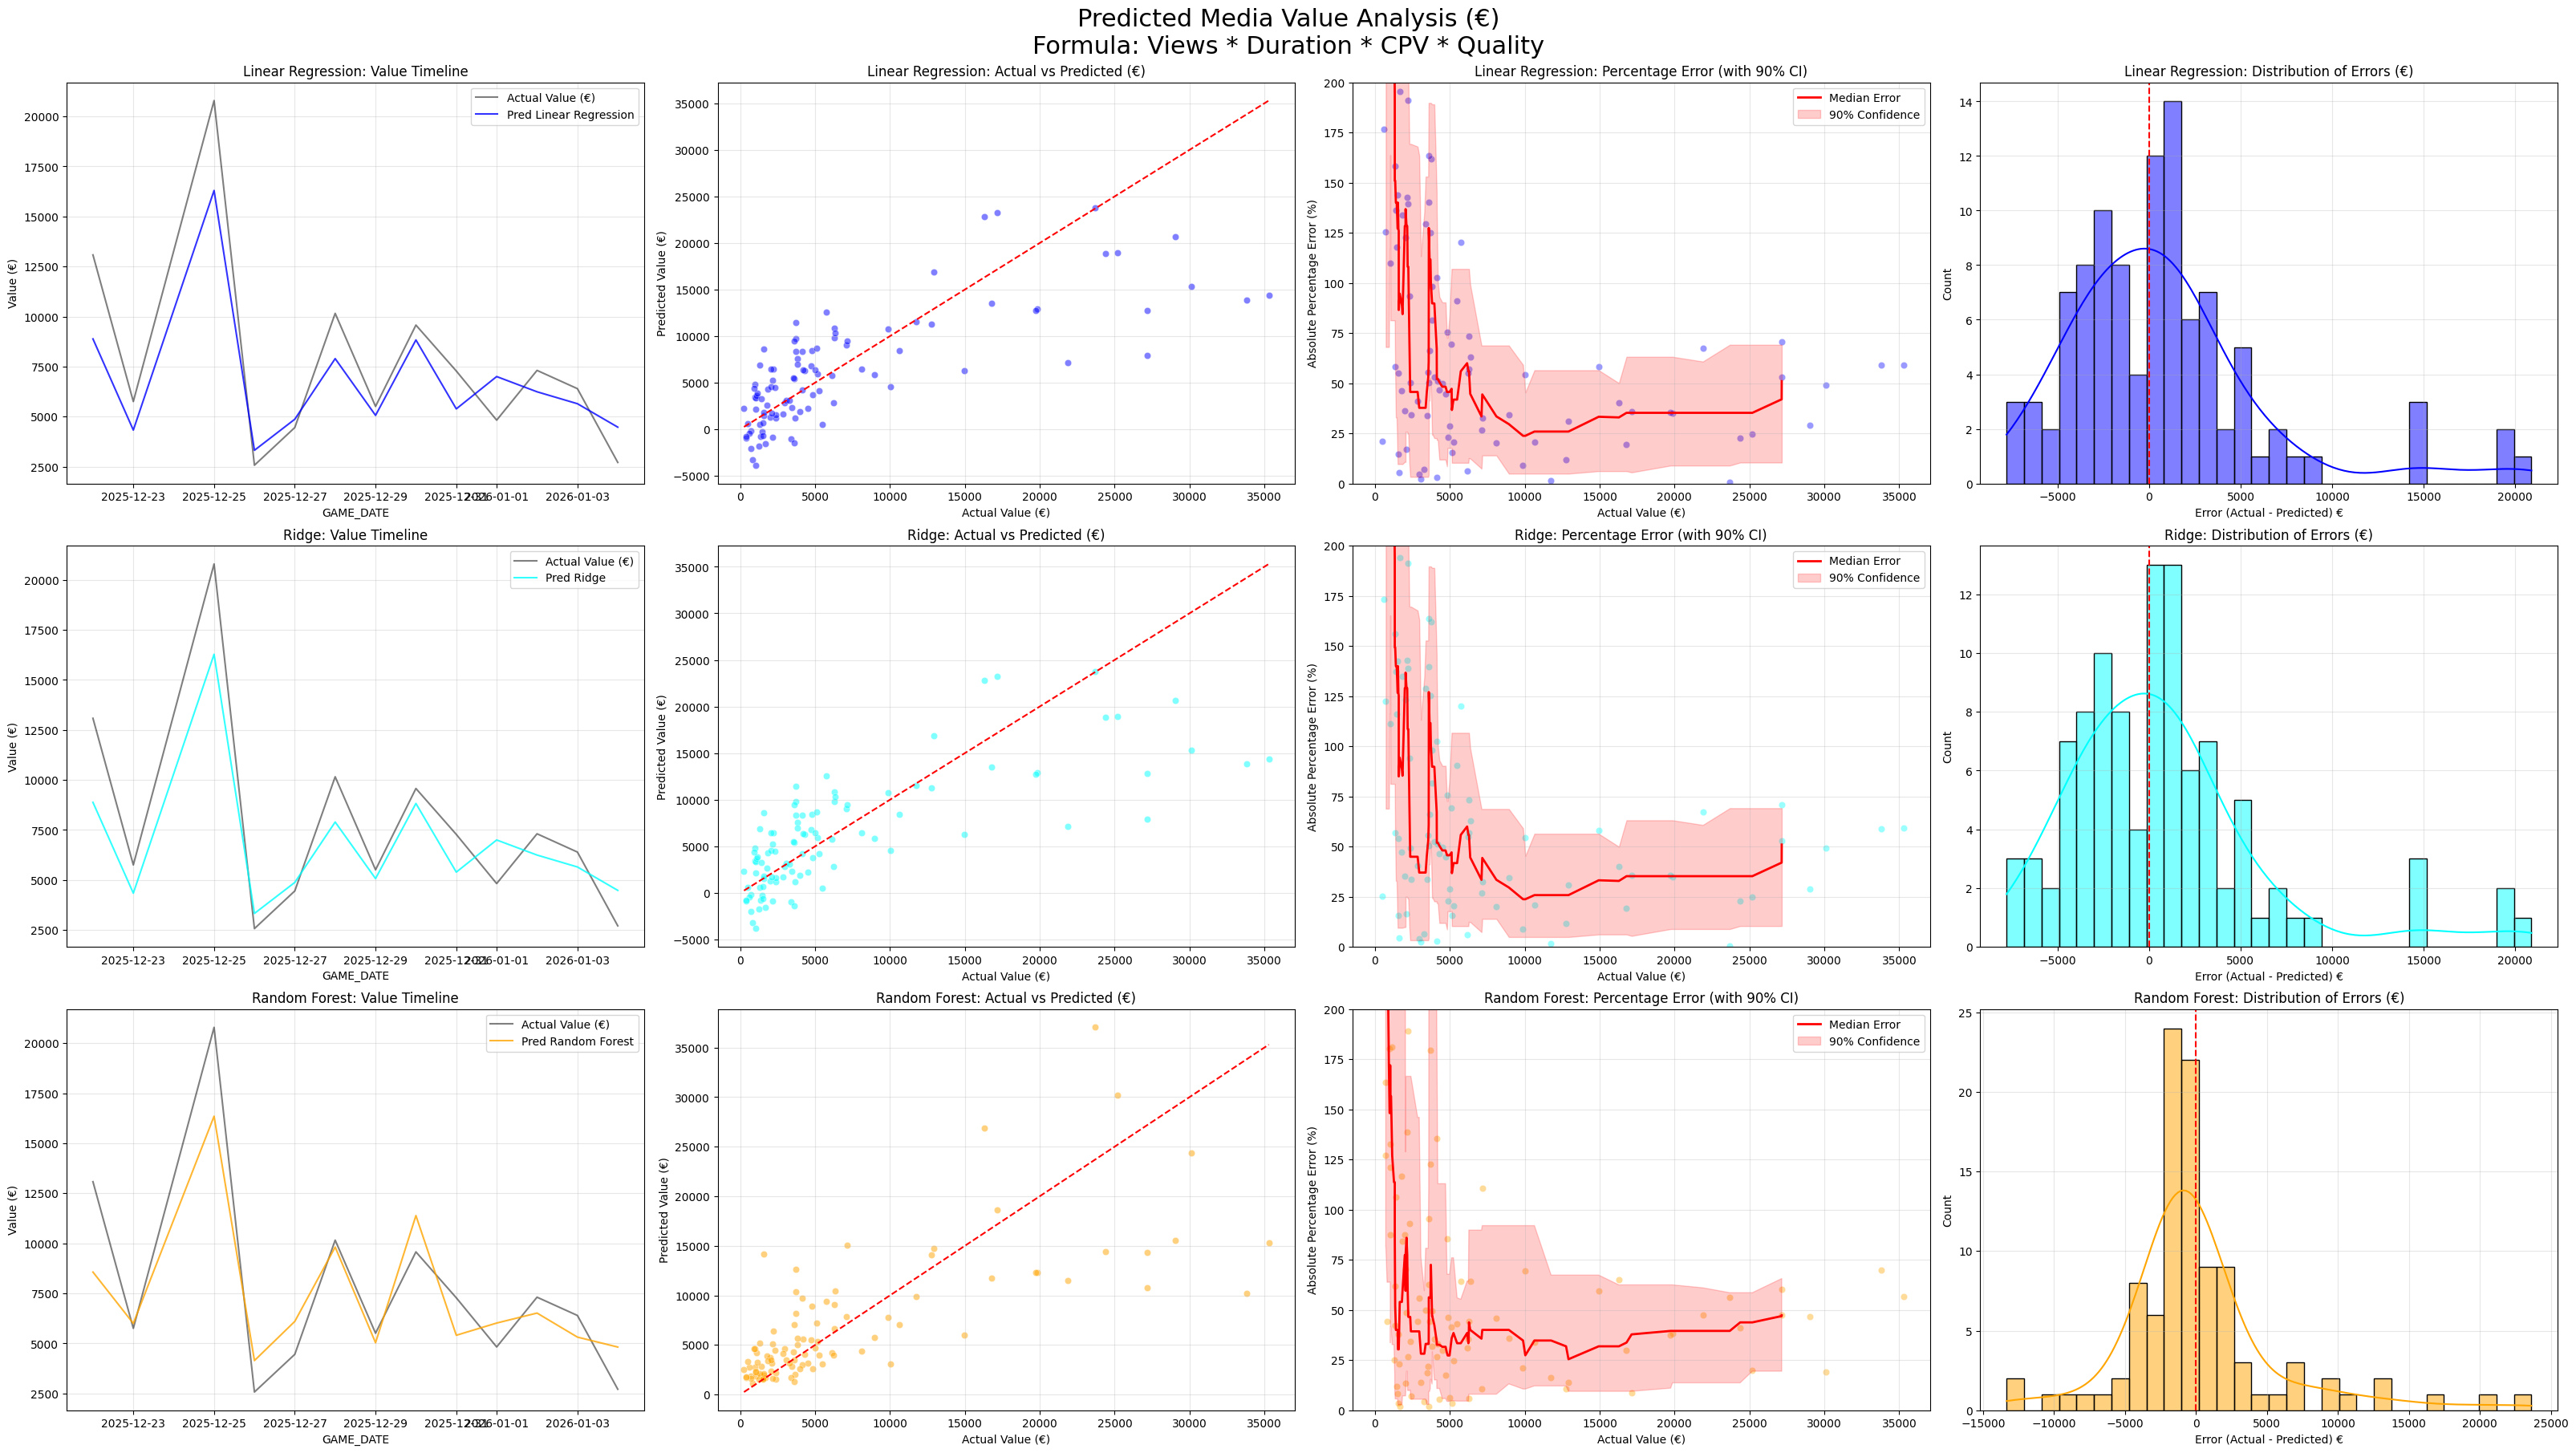

In [106]:
# 7. FINANCIAL VALUE ESTIMATION & EVALUATION

# Default values for unseen teams (safety check)
default_quality = np.mean(list(dict_arena_quality.values()))
default_duration = np.mean(list(dict_arena_duration.values()))

# Value Calculation Formula
def calculate_value(views_array, team_ids_array, quality_dict, duration_dict, cpv):
    """
    Business Formula: Value = Views * Duration * CPV * Quality_Score
    """
    # Map IDs to their specific Quality Score (default if unknown)
    quality_scores = np.array([quality_dict.get(tid, default_quality) for tid in team_ids_array])
    
    # Map IDs to their specific Avg Duration (default if unknown)
    durations = np.array([duration_dict.get(tid, default_duration) for tid in team_ids_array])
    
    return views_array * durations * cpv * quality_scores

# Calculate Ground Truth (Actual Value)
# We need the Home Team IDs corresponding to the Test Set
test_home_ids = meta_test['HOME_TEAM_ID'].values

# We apply the formula to the ACTUAL views (y_test) to get the "True Value"
y_test_real_value = calculate_value(y_test, test_home_ids, dict_arena_quality, dict_arena_duration, CPV)

# Convert Model Predictions (Views -> Value)
results_value = {}

# We iterate over the results from Section 6 (No re-training needed)
for name, data in results.items():
    # 1. Get existing View Predictions
    preds_views = data['preds'] 
    
    # 2. Convert to Value (€)
    preds_value = calculate_value(preds_views, test_home_ids, dict_arena_quality, dict_arena_duration, CPV)
    
    # 3. Calculate Metrics on Value
    mae = mean_absolute_error(y_test_real_value, preds_value)
    rmse = np.sqrt(mean_squared_error(y_test_real_value, preds_value))
    r2 = r2_score(y_test_real_value, preds_value)
    
    # 4. Store for visualization
    results_value[name] = {
        'preds': preds_value,
        'color': data['color'] # Keep same color consistency
    }
    
    print(f"--- Results for: {name} ---")
    print(f"MAE  : {mae:.2f} €")
    print(f"RMSE : {rmse:.2f} €")
    print(f"R²   : {r2:.4f}")
    print("-" * 30)

# FINANCIAL VISUALIZATION
# ---------------------------------------------------------
df_viz = meta_test.copy()
df_viz['Reel_Value'] = y_test_real_value

model_names = ['Linear', 'Ridge', 'RandomForest']
display_names = ['Linear Regression', 'Ridge', 'Random Forest']

# Updated Layout: 3 rows, 4 columns (matching Section 6 style)
fig, axes = plt.subplots(3, 4, figsize=(32, 18), constrained_layout=True)

for i, name in enumerate(model_names):
    preds = results_value[name]['preds']
    color = results_value[name]['color']
    disp_name = display_names[i]
    
    # Error calculations
    errors = df_viz['Reel_Value'] - preds       # Real Error (positive or negative)
    abs_errors = np.abs(errors)                 # Absolute Error
    
    # --- Col 1: Timeline ---
    sns.lineplot(data=df_viz, x='GAME_DATE', y='Reel_Value', label='Actual Value (€)', 
                 alpha=0.5, color='black', errorbar=None, ax=axes[i, 0])
    sns.lineplot(x=df_viz['GAME_DATE'], y=preds, label=f'Pred {disp_name}', 
                 alpha=0.8, color=color, errorbar=None, ax=axes[i, 0])
    axes[i, 0].set_title(f'{disp_name}: Value Timeline')
    axes[i, 0].set_ylabel('Value (€)')
    axes[i, 0].grid(True, alpha=0.3)
    
    # --- Col 2: Scatter (Actual vs Pred) ---
    sns.scatterplot(x=df_viz['Reel_Value'], y=preds, alpha=0.5, color=color, ax=axes[i, 1])
    min_val, max_val = df_viz['Reel_Value'].min(), df_viz['Reel_Value'].max()
    axes[i, 1].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')
    axes[i, 1].set_title(f'{disp_name}: Actual vs Predicted (€)')
    axes[i, 1].set_xlabel('Actual Value (€)')
    axes[i, 1].set_ylabel('Predicted Value (€)')
    axes[i, 1].grid(True, alpha=0.3)
    
    # --- Col 3: Percentage Error with Confidence Interval ---
    # Calculate percentage error (avoiding division by zero)
    pct_errors = np.where(df_viz['Reel_Value'] != 0, 
                          (abs_errors / df_viz['Reel_Value']) * 100, 
                          0)
    
    # Plot scatter of percentage errors
    sns.scatterplot(x=df_viz['Reel_Value'], y=pct_errors, alpha=0.4, color=color, ax=axes[i, 2])
    
    # Calculate rolling statistics for confidence interval
    # Sort by actual values for smooth confidence band
    sorted_indices = np.argsort(df_viz['Reel_Value'])
    sorted_actual = df_viz['Reel_Value'].iloc[sorted_indices]
    sorted_pct_errors = pct_errors[sorted_indices]
    
    # Calculate moving average and percentiles (90% confidence interval)
    window_size = max(10, len(sorted_actual) // 20)  # Adaptive window
    rolling_median = pd.Series(sorted_pct_errors).rolling(window=window_size, center=True).median()
    rolling_p5 = pd.Series(sorted_pct_errors).rolling(window=window_size, center=True).quantile(0.05)
    rolling_p95 = pd.Series(sorted_pct_errors).rolling(window=window_size, center=True).quantile(0.95)
    
    # Plot median line and confidence band
    axes[i, 2].plot(sorted_actual, rolling_median, color='red', linewidth=2, label='Median Error')
    axes[i, 2].fill_between(sorted_actual, rolling_p5, rolling_p95, 
                            color='red', alpha=0.2, label='90% Confidence')
    
    axes[i, 2].set_title(f'{disp_name}: Percentage Error (with 90% CI)')
    axes[i, 2].set_xlabel('Actual Value (€)')
    axes[i, 2].set_ylabel('Absolute Percentage Error (%)')
    axes[i, 2].set_ylim(0, min(200, np.percentile(pct_errors, 99)))  # Cap at 200% or 99th percentile
    axes[i, 2].legend(loc='upper right')
    axes[i, 2].grid(True, alpha=0.3)

    # --- Col 4: Error Distribution ---
    sns.histplot(errors, kde=True, color=color, ax=axes[i, 3], bins=30)
    axes[i, 3].axvline(0, color='red', linestyle='--', label='Zero Error')
    axes[i, 3].set_title(f'{disp_name}: Distribution of Errors (€)')
    axes[i, 3].set_xlabel('Error (Actual - Predicted) €')
    axes[i, 3].grid(True, alpha=0.3)

plt.suptitle("Predicted Media Value Analysis (€)\nFormula: Views * Duration * CPV * Quality", fontsize=22)
plt.show()